In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from IPython.display import Image
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline, HuggingFaceEmbeddings, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.runnables import RunnablePassthrough

from langgraph.checkpoint.memory import InMemorySaver # for checkpointing and time travel

d:\Softwares\DL\conda\envs\lc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
hf_llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=120,
    temperature=0.7,
)
llm = ChatHuggingFace(llm=hf_llm)

In [3]:
class StoryClass(TypedDict):
    topic: str
    title: str
    content: str
    
checkPointer = InMemorySaver() # create a checkpoint manager - store data in memory

In [4]:
# Threads in Persistence
CONFIG = {
    "configurable": {
        "thread_id": "story_generation_thread"
    }
}

In [5]:
def generate_title(StoryClass):
    prompt = f"Generate one title for a story with the following topic: {StoryClass['topic']}"
    title = llm.invoke(prompt).content
    return {
        "title": title
    }

In [6]:
def generate_story(StoryClass):
    prompt = f"Generate a 50 words story with the following topic: {StoryClass['topic']}"
    content = llm.invoke(prompt).content
    return {
        "content": content
    }

In [7]:
# Graph
graph = StateGraph(StoryClass)

# Nodes
graph.add_node("generate_title", generate_title)
graph.add_node("generate_story", generate_story)

# Edges
graph.add_edge(START, "generate_title")
graph.add_edge("generate_title", "generate_story")
graph.add_edge("generate_story", END)

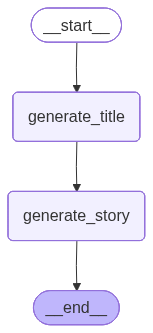

In [8]:
workflow = graph.compile(
    checkpointer=checkPointer # compile the graph with checkpointing enabled
) 
Image(workflow.get_graph().draw_mermaid_png())

In [9]:
def call_workflow(initial_state):
    result = workflow.invoke(
        initial_state,
        config=CONFIG # thread_id uniquely idenitfy a execution
    )
    return result

# if title or content not provided, langgraph treats them as key not provided
state1 = StoryClass(topic="A brave knight", title="", content="")
state2 = StoryClass(topic="Super fast car", title="", content="")

In [10]:
result1 = call_workflow(state1)
result2 = call_workflow(state2)

In [11]:
print("Result 1 *********************************")
print("Query Topic: ", result1["topic"])
print("Result Title: ", result1["title"])
print("Result Content: ", result1["content"])

print("\n\nResult 2 *********************************")
print("Query Topic: ", result2["topic"])
print("Result Title: ", result2["title"])
print("Result Content: ", result2["content"])

Result 1 *********************************
Query Topic:  A brave knight
Result Title:  "The Valor of Sir Edward: A Tale of Unyielding Courage"
Result Content:  Sir Edward, a gallant knight, charged into the dark forest, his armor shining with valor. With sword in hand, he battled fierce dragons and defeated them. As the sun rose, a village maiden thanked him, her smile illuminating the land. The brave knight had saved the village from eternal night.


Result 2 *********************************
Query Topic:  Super fast car
Result Title:  "Reaching the Edge of Velocity."
Result Content:  As the engine roared to life, Jack floored it, feeling the rush of adrenaline. His sleek, black supercar surged forward, accelerating from 0 to 60 in seconds. The speedometer needle danced above 200, the wind whipping through his hair. The open road stretched out before him, endless and free.


Persistence and Threads

In [12]:
# Snapshots - Persistence - requires thread_id in config - give current state of the thread
workflow.get_state(CONFIG)

StateSnapshot(values={'topic': 'Super fast car', 'title': '"Reaching the Edge of Velocity."', 'content': 'As the engine roared to life, Jack floored it, feeling the rush of adrenaline. His sleek, black supercar surged forward, accelerating from 0 to 60 in seconds. The speedometer needle danced above 200, the wind whipping through his hair. The open road stretched out before him, endless and free.'}, next=(), config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e210-a54f-673e-8006-f84f98bb0cc3'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-03-12T14:37:48.129055+00:00', parent_config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e210-9500-6004-8005-d80817782be6'}}, tasks=(), interrupts=())

In [13]:
list(workflow.get_state_history(CONFIG)) # return generator, so requires list() to display all states in the thread history

[StateSnapshot(values={'topic': 'Super fast car', 'title': '"Reaching the Edge of Velocity."', 'content': 'As the engine roared to life, Jack floored it, feeling the rush of adrenaline. His sleek, black supercar surged forward, accelerating from 0 to 60 in seconds. The speedometer needle danced above 200, the wind whipping through his hair. The open road stretched out before him, endless and free.'}, next=(), config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e210-a54f-673e-8006-f84f98bb0cc3'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-03-12T14:37:48.129055+00:00', parent_config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e210-9500-6004-8005-d80817782be6'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Super fast car', 'title': '"Reaching the Edge of Velocity."', 'content': ''}, next=('generate_story',), config={'configurable': {

#### Time Travel

Getting state based on check point id

In [20]:
stateObjList = list(workflow.get_state_history(CONFIG))
stateObj = stateObjList[1]
test_checkpoint_id = stateObj.config['configurable']['checkpoint_id']

In [22]:
# Car Story - Title generated but not content
workflow.get_state(
    {
        "configurable": {
            "thread_id": CONFIG["configurable"]["thread_id"],
            "checkpoint_id": test_checkpoint_id
        }
    }
)

StateSnapshot(values={'topic': 'Super fast car', 'title': '"Reaching the Edge of Velocity."', 'content': ''}, next=('generate_story',), config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_id': '1f11e210-9500-6004-8005-d80817782be6'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-03-12T14:37:46.418790+00:00', parent_config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e210-8bac-61f2-8004-77b6b00d1c54'}}, tasks=(PregelTask(id='e6b3d68f-b882-6fdd-2c04-bd85e4b76041', name='generate_story', path=('__pregel_pull', 'generate_story'), error=None, interrupts=(), state=None, result={'content': 'As the engine roared to life, Jack floored it, feeling the rush of adrenaline. His sleek, black supercar surged forward, accelerating from 0 to 60 in seconds. The speedometer needle danced above 200, the wind whipping through his hair. The open road stretched out before him, endless and free.'}),), i

Executing Workflow from checkpoint

In [23]:
workflow.invoke(
    None,
        {
        "configurable": {
            "thread_id": CONFIG["configurable"]["thread_id"],
            "checkpoint_id": test_checkpoint_id
        }
    }
)

{'topic': 'Super fast car',
 'title': '"Reaching the Edge of Velocity."',
 'content': 'As the lights turned green, Jack floored it, and his sleek, black supercar shot forward like a bullet. The speedometer climbed to 200, then 250, and finally 300 miles per hour. The wind whipped through his hair as he sped past a stunned highway patrolman, who could only watch in awe.'}

Updating Workflow State

In [32]:
stateObjList2 = list(workflow.get_state_history(CONFIG))
stateObj2 = stateObjList2[2]
update_checkpoint_id = stateObj.config['configurable']['checkpoint_id']
update_checkpoint_ns = stateObj.config['configurable']['checkpoint_ns']
stateObj2

StateSnapshot(values={'topic': 'Super fast car', 'title': '"Reaching the Edge of Velocity."', 'content': ''}, next=('generate_story',), config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e210-9500-6004-8005-d80817782be6'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-03-12T14:37:46.418790+00:00', parent_config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e210-8bac-61f2-8004-77b6b00d1c54'}}, tasks=(PregelTask(id='e6b3d68f-b882-6fdd-2c04-bd85e4b76041', name='generate_story', path=('__pregel_pull', 'generate_story'), error=None, interrupts=(), state=None, result={'content': 'As the engine roared to life, Jack floored it, feeling the rush of adrenaline. His sleek, black supercar surged forward, accelerating from 0 to 60 in seconds. The speedometer needle danced above 200, the wind whipping through his hair. The open road stretched out before him, endl

In [33]:
workflow.update_state({
        "configurable": {
            "thread_id": CONFIG["configurable"]["thread_id"],
            "checkpoint_id": update_checkpoint_id,
            "checkpoint_ns": update_checkpoint_ns
        }
    },
    {
        "content": "The Fast and The Curious",
    }
)

{'configurable': {'thread_id': 'story_generation_thread',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11e227-b600-6062-8006-130c65252ded'}}

In [35]:
stateObjList3 = list(workflow.get_state_history(CONFIG))

updates_state = stateObjList3[0] # updated state is added as the latest state in the history
updates_state

StateSnapshot(values={'topic': 'Super fast car', 'title': '"Reaching the Edge of Velocity."', 'content': 'The Fast and The Curious'}, next=('generate_story',), config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e227-b600-6062-8006-130c65252ded'}}, metadata={'source': 'update', 'step': 6, 'parents': {}}, created_at='2026-03-12T14:48:07.280649+00:00', parent_config={'configurable': {'thread_id': 'story_generation_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f11e210-9500-6004-8005-d80817782be6'}}, tasks=(PregelTask(id='e72a732f-9d97-4236-1135-f8609879b166', name='generate_story', path=('__pregel_pull', 'generate_story'), error=None, interrupts=(), state=None, result=None),), interrupts=())